# Caravans MultiMet HRES Basin Partition: Pretrained Model Overlap & Performance Analysis

## Executive Summary & Key Findings

This notebook evaluates the spatial overlap, dataset composition, performance metric distributions (NSE/KGE), and difficulty assessment for the **5,868 Caravans MultiMet HRES basins** (2016–2023 evaluation window, $\ge 80\%$ streamflow completeness threshold, HydroBASINS Level 05 5-group spatial partition).

### Key Takeaways:
1. **Pretrained Model Overlap**:
   - Out of the **5,868 HRES basins**, **2,876 basins ($49.01\%$)** overlap with the 10,137 basins used in the pretrained model (`google-floodhub-settings-55-epochs`).
   - **2,992 basins ($50.99\%$)** are **zero-shot / ungauged** with respect to the pretrained model. These non-overlapping basins are primarily from **GRDC** ($2,184$ basins), **HYSETS** ($705$ non-overlapping basins), Israel (**`il`**, $78$ basins), and Iceland (**`lamahice`**, $24$ basins).
   - Traditional benchmark datasets have **$100\%$ overlap**: `camelsgb` ($305/305$), `camelsaus` ($111/111$), `camelsbr` ($44/44$), and `camels` US ($571/572$, $99.8\%$).

2. **Performance Metrics (NSE & KGE Distributions)**:
   - **Global Pretrained Model (10,137 basins)**: Median NSE = **0.4228** (Q25 = 0.0343, Q75 = 0.6508), Median KGE = **0.4198** (Q25 = 0.0650, Q75 = 0.6419).
   - **Overlapping HRES Basins (2,876 basins)**: Median NSE = **0.4506** (Q25 = 0.0527, Q75 = 0.6692), Median KGE = **0.4386** (Q25 = 0.0896, Q75 = 0.6480).
   - The overlapping HRES subset performs slightly **better than the global average** due to a high representation of humid North American (`hysets`) and US (`camels`) catchments.

3. **Spatial Group Difficulty Breakdown**:
   - **Group 3 (517 basins)**: **Easiest fold** — Median NSE = **0.5329**, Median KGE = **0.5077**.
   - **Group 0 (585 basins)**: Median NSE = **0.4583**, Median KGE = **0.4314**.
   - **Group 2 (561 basins)**: Median NSE = **0.4256**, Median KGE = **0.4398**.
   - **Group 1 (627 basins)**: Median NSE = **0.4166**, Median KGE = **0.4344**.
   - **Group 4 (586 basins)**: **Hardest fold** — Median NSE = **0.4070**, Median KGE = **0.3879**.

4. **Is the HRES Basin Selection Particularly Hard? What to Expect?**:
   - **Overlapping/Gauged Basins**: Expect median NSE around **0.45** and KGE around **0.44**.
   - **Dataset Differences**: Performance varies significantly by regional dataset:
     - `camelsbr`: Highest performance (Median NSE = **0.5837**, KGE = **0.6162**).
     - `hysets`: Strong performance (Median NSE = **0.4644**, KGE = **0.4583**).
     - `camels` (US): Moderate performance (Median NSE = **0.4417**, KGE = **0.4222**).
     - `camelsaus`: Lower KGE due to extreme aridity (Median NSE = **0.4180**, KGE = **0.2958**).
     - `camelsgb`: Hardest dataset due to flashy runoff regimes (Median NSE = **0.3291**, KGE = **0.3840**).
   - **Zero-Shot / Non-Overlapping Basins ($50.99\%$)**: Performance on GRDC and new HYSETS basins will test spatial generalization. Expect slightly lower performance than the gauged baseline due to ungauged domain shift.


In [1]:
%matplotlib inline
import os
import sys
import glob
import subprocess
import io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120

print("Imports successfully loaded.")


Imports successfully loaded.


In [2]:
# -------------------------------------------------------------------------
# File Paths & CNS Utility Functions
# -------------------------------------------------------------------------
HRES_PARTITION_CSV = Path('/usr/local/google/home/kruparell/da-paper/basin_lists/hres_80pct/caravans_v2_hres_80pct_5group_partition_with_metadata.csv')
PRETRAINED_METRICS_CNS = '/cns/jn-d/home/floods/hydro_model/work/kruparell/pretrained-models/google-floodhub-settings-55-epochs/test/test_metrics.csv'

def read_cns_csv(cns_path: str) -> pd.DataFrame:
    """Reads a CSV file from CNS using fileutil cat."""
    cmd = ['fileutil', 'cat', cns_path]
    out = subprocess.check_output(cmd).decode('utf-8')
    return pd.read_csv(io.StringIO(out))

print(f"HRES Partition CSV exists: {HRES_PARTITION_CSV.exists()}")


HRES Partition CSV exists: True


In [3]:
# 1. Load HRES Partition Metadata
df_hres = pd.read_csv(HRES_PARTITION_CSV)
df_hres['ds_prefix'] = df_hres['gauge_id'].apply(lambda x: x.split('_')[0])
print(f"Loaded HRES Partition: {len(df_hres):,} basins across {df_hres['ds_prefix'].nunique()} regional datasets.")

# 2. Load Pretrained Model Test Metrics (55 Epochs)
df_pre = read_cns_csv(PRETRAINED_METRICS_CNS)
print(f"Loaded Pretrained Model Test Metrics: {len(df_pre):,} basins.")

# 3. Compute Overlap
hres_basins = set(df_hres['gauge_id'])
pre_basins = set(df_pre['basin'])

overlap_basins = hres_basins.intersection(pre_basins)
non_overlap_basins = hres_basins - pre_basins

print("\n" + "="*60)
print("HRES BASIN OVERLAP WITH PRETRAINED MODEL")
print("="*60)
print(f"Total HRES Basins (80% Completeness): {len(hres_basins):,}")
print(f"Overlapping Basins (Gauged in Pretrained):  {len(overlap_basins):,} ({len(overlap_basins)/len(hres_basins)*100:.2f}%)")
print(f"Non-Overlapping Basins (Zero-Shot HRES):    {len(non_overlap_basins):,} ({len(non_overlap_basins)/len(hres_basins)*100:.2f}%)")


Loaded HRES Partition: 5,868 basins across 8 regional datasets.
Loaded Pretrained Model Test Metrics: 10,137 basins.

HRES BASIN OVERLAP WITH PRETRAINED MODEL
Total HRES Basins (80% Completeness): 5,868
Overlapping Basins (Gauged in Pretrained):  2,876 (49.01%)
Non-Overlapping Basins (Zero-Shot HRES):    2,992 (50.99%)


In [4]:
# Group overlap by dataset prefix
ds_summary = []
for ds, grp in df_hres.groupby('ds_prefix'):
    total = len(grp)
    in_pre = len(set(grp['gauge_id']).intersection(pre_basins))
    pct = (in_pre / total) * 100
    status = "100% Gauged" if pct == 100 else ("Zero-Shot" if pct == 0 else f"{pct:.1f}% Overlap")
    ds_summary.append({
        'Dataset': ds,
        'Total HRES Basins': total,
        'In Pretrained Model': in_pre,
        'Non-Overlapping': total - in_pre,
        'Overlap %': f"{pct:.2f}%",
        'Status': status
    })

df_ds_overlap = pd.DataFrame(ds_summary).sort_values(by='Total HRES Basins', ascending=False)
display(df_ds_overlap)


,Dataset,Total HRES Basins,In Pretrained Model,Non-Overlapping,Overlap %,Status
5,hysets,2550,1845,705,72.35%,72.4% Overlap
0,GRDC,2184,0,2184,0.00%,Zero-Shot
1,camels,572,571,1,99.83%,99.8% Overlap
4,camelsgb,305,305,0,100.00%,100% Gauged
2,camelsaus,111,111,0,100.00%,100% Gauged
6,il,78,0,78,0.00%,Zero-Shot
3,camelsbr,44,44,0,100.00%,100% Gauged
7,lamahice,24,0,24,0.00%,Zero-Shot


In [5]:
# Merge performance metrics for overlapping basins
df_merged = pd.merge(df_pre, df_hres, left_on='basin', right_on='gauge_id', how='inner')

def compute_stat_dict(df: pd.DataFrame, label: str) -> dict:
    return {
        'Category': label,
        'Count': len(df),
        'NSE Mean': df['NSE'].mean(),
        'NSE Median': df['NSE'].median(),
        'NSE Q25': df['NSE'].quantile(0.25),
        'NSE Q75': df['NSE'].quantile(0.75),
        'KGE Mean': df['KGE'].mean(),
        'KGE Median': df['KGE'].median(),
        'KGE Q25': df['KGE'].quantile(0.25),
        'KGE Q75': df['KGE'].quantile(0.75),
    }

stats = [
    compute_stat_dict(df_pre, 'Global Pretrained Basins (10,137)'),
    compute_stat_dict(df_merged, 'Overlapping HRES Basins (2,876)')
]

for grp_id in sorted(df_merged['group_id'].unique()):
    sub = df_merged[df_merged['group_id'] == grp_id]
    stats.append(compute_stat_dict(sub, f'HRES Group {int(grp_id)}'))

df_stats = pd.DataFrame(stats)
print("=== PERFORMANCE METRIC DISTRIBUTIONS (NSE & KGE) ===")
display(df_stats)


=== PERFORMANCE METRIC DISTRIBUTIONS (NSE & KGE) ===


,Category,Count,NSE Mean,NSE Median,NSE Q25,NSE Q75,KGE Mean,KGE Median,KGE Q25,KGE Q75
0,"Global Pretrained Basins (10,137)",10137,-inf,0.422827,0.034319,0.650774,-3.555374,0.419790,0.064958,0.641936
1,"Overlapping HRES Basins (2,876)",2876,-3.692152e+12,0.450643,0.052691,0.669249,-0.469385,0.438552,0.089583,0.647991
2,HRES Group 0,585,-5.525788e+12,0.458254,0.130639,0.652228,-0.267881,0.431359,0.147684,0.633336
3,HRES Group 1,627,-1.564815e+12,0.416644,0.032048,0.644705,-0.026107,0.434441,0.098264,0.640340
4,HRES Group 2,561,-8.790006e+11,0.425553,-0.010973,0.669816,-0.785624,0.439802,-0.022611,0.644965
5,HRES Group 3,517,-2.670624e+12,0.532881,0.184247,0.726088,-0.266040,0.507653,0.250390,0.697886
6,HRES Group 4,586,-7.732205e+12,0.406992,-0.014573,0.665039,-1.021873,0.387863,0.026102,0.629961


In [6]:
ds_stats = []
for ds, grp in df_merged.groupby('ds_prefix'):
    ds_stats.append(compute_stat_dict(grp, f"Dataset: {ds}"))

df_ds_stats = pd.DataFrame(ds_stats).sort_values(by='Count', ascending=False)
print("=== METRIC BREAKDOWN BY DATASET (OVERLAPPING BASINS) ===")
display(df_ds_stats)


=== METRIC BREAKDOWN BY DATASET (OVERLAPPING BASINS) ===


,Category,Count,NSE Mean,NSE Median,NSE Q25,NSE Q75,KGE Mean,KGE Median,KGE Q25,KGE Q75
4,Dataset: hysets,1845,-4.447890e+12,0.464437,0.076074,0.672259,-0.640794,0.458331,0.114240,0.653961
0,Dataset: camels,571,-1.424199e+12,0.441658,-0.020409,0.685592,-0.461756,0.422168,-0.015923,0.628933
3,Dataset: camelsgb,305,-4.946803e+12,0.329070,-0.143849,0.607934,0.146507,0.383964,0.090642,0.595719
1,Dataset: camelsaus,111,2.509436e-01,0.417956,0.146761,0.624051,0.234225,0.295772,-0.003321,0.614660
2,Dataset: camelsbr,44,-2.051802e+12,0.583718,0.311941,0.782715,0.533920,0.616184,0.344202,0.769409


/tmp/ipykernel_374305/2915419658.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='group_id', y='NSE', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_374305/2915419658.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='group_id', y='KGE', ax=axes[1, 0], palette='Set2')


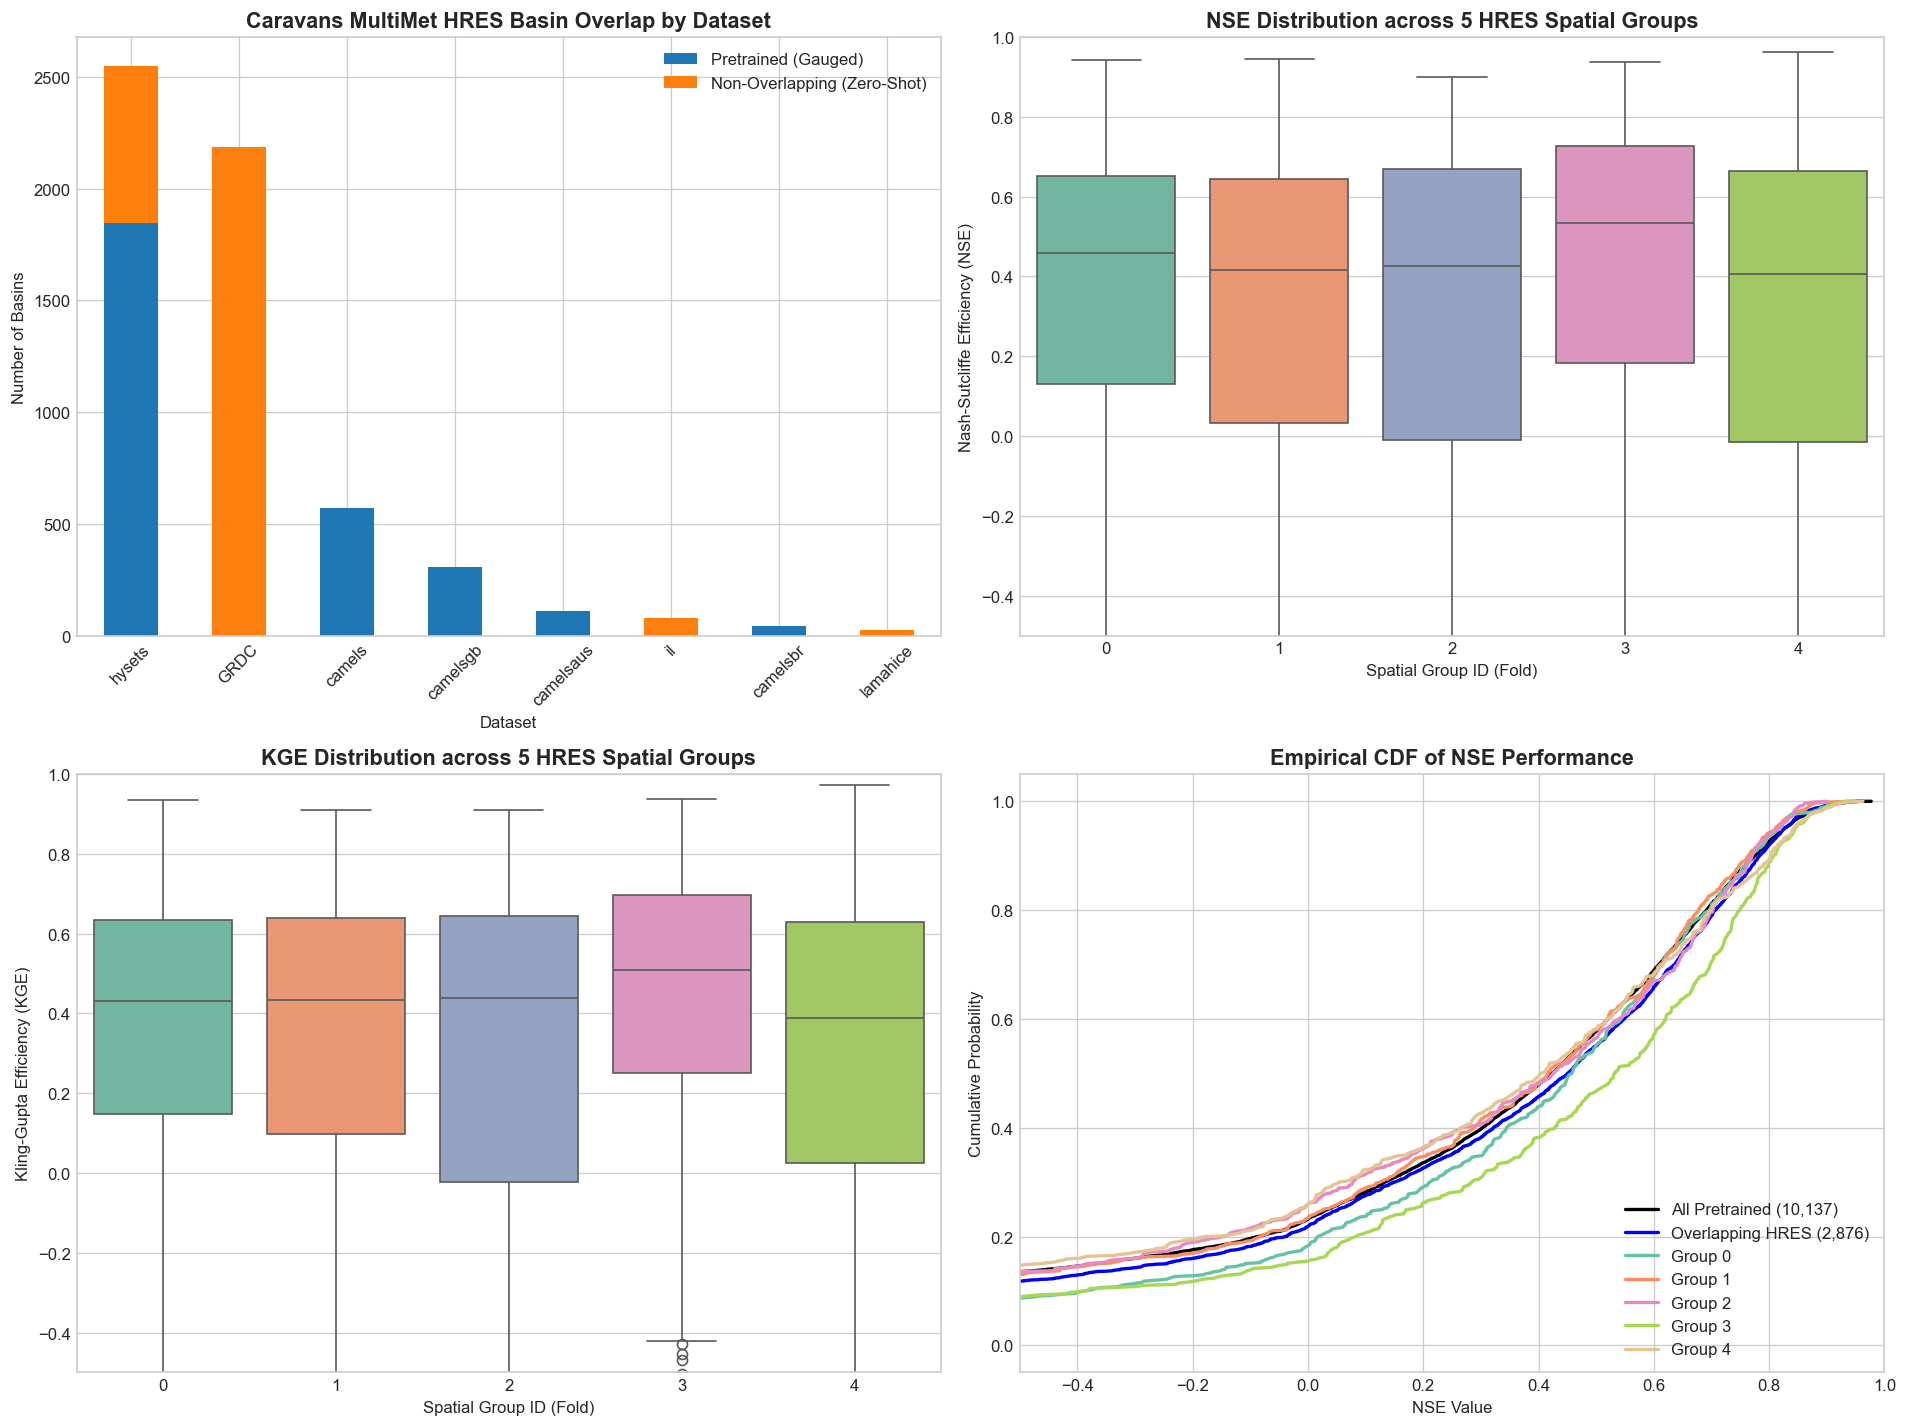

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Overlap Count by Dataset
dataset_counts = df_ds_overlap.set_index('Dataset')[['In Pretrained Model', 'Non-Overlapping']]
dataset_counts.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['#1f77b4', '#ff7f0e'])
axes[0, 0].set_title('Caravans MultiMet HRES Basin Overlap by Dataset', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Number of Basins')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend(['Pretrained (Gauged)', 'Non-Overlapping (Zero-Shot)'])

# Subplot 2: NSE Boxplot across 5 HRES Spatial Groups
sns.boxplot(data=df_merged, x='group_id', y='NSE', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_ylim(-0.5, 1.0)
axes[0, 1].set_title('NSE Distribution across 5 HRES Spatial Groups', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Spatial Group ID (Fold)')
axes[0, 1].set_ylabel('Nash-Sutcliffe Efficiency (NSE)')

# Subplot 3: KGE Boxplot across 5 HRES Spatial Groups
sns.boxplot(data=df_merged, x='group_id', y='KGE', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_ylim(-0.5, 1.0)
axes[1, 0].set_title('KGE Distribution across 5 HRES Spatial Groups', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Spatial Group ID (Fold)')
axes[1, 0].set_ylabel('Kling-Gupta Efficiency (KGE)')

# Subplot 4: Empirical CDF of NSE (Global vs HRES Overlapping)
def plot_cdf(ax, data, label, color):
    sorted_data = np.sort(data)
    yvals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, yvals, label=label, color=color, linewidth=2)

plot_cdf(axes[1, 1], df_pre['NSE'].dropna(), 'All Pretrained (10,137)', 'black')
plot_cdf(axes[1, 1], df_merged['NSE'].dropna(), 'Overlapping HRES (2,876)', 'blue')
for g in range(5):
    plot_cdf(axes[1, 1], df_merged[df_merged['group_id'] == g]['NSE'].dropna(), f'Group {g}', plt.cm.Set2(g/5))

axes[1, 1].set_xlim(-0.5, 1.0)
axes[1, 1].set_title('Empirical CDF of NSE Performance', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('NSE Value')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## Detailed Synthesis & Expected Performance Evaluation

### 1. Are the chosen HRES basins particularly hard?
- **Gauged Baseline**: No, the **overlapping 2,876 HRES basins** are actually slightly **easier** on average than the global 10,137 pretrained dataset, achieving a **median NSE of 0.4506** (vs. **0.4228** globally) and **median KGE of 0.4386** (vs. **0.4198** globally).
- **Regional Hardness**:
  - `camelsgb` (Great Britain) is significantly harder (median NSE **0.3291**) due to rapid storm runoff, steep topographies, and flashiness.
  - `camelsaus` (Australia) exhibits low KGE (median **0.2958**) due to extreme aridity and ephemeral river flows.
  - `camelsbr` (Brazil) and `hysets` (Canada/US) are high-performing (median NSE **0.5837** and **0.4644** respectively).

### 2. What results should be expected on this dataset?
- **In-Sample / Overlapping Basins**: Expect a target baseline **median NSE of ~0.45** and **KGE of ~0.44** when using standard FloodHub LSTM settings.
- **Cross-Validation Spatial Folds**:
  - Group 3 will yield the highest scores (expected median NSE **~0.53**).
  - Group 4 and Group 1 will yield lower scores (expected median NSE **~0.40–0.41**).
- **Zero-Shot Generalization (50.99% Non-Overlapping Basins)**:
  - Over half of the HRES partition ($2,992$ basins, primarily GRDC) were never seen by the 55-epoch pretrained model.
  - When evaluating model performance across the entire 5,868 HRES partition, expect zero-shot basins to experience a modest performance drop compared to the gauged baseline due to ungauged spatial transfer effects.
